In [102]:
# Import Libraries

import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    learning_curve,
    validation_curve
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    PrecisionRecallDisplay,
    RocCurveDisplay,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss
)

from sklearn.inspection import permutation_importance

In [103]:
# Load Dataset

df = pd.read_csv(
    "/content/drive/MyDrive/Heart Disease Cleveland UCI/heart_cleveland_upload.csv"
)

In [104]:
# Dataset Overview

display(df.head())

print("\nShape:", df.shape)
# Dataset Information

df.info()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0



Shape: (297, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB


In [105]:
# Missing Values

print(df.isnull().sum())

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64


In [106]:
# Features and Target

X = df.drop("condition", axis=1)

y = df["condition"]

print(X.head())

print(y.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  
0   1     0  
1   2     0  
2   0     0  
3   1     0  
4   0     0  
0    0
1    0
2    0
3    1
4    0
Name: condition, dtype: int64


In [107]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [108]:
# Import Decision Tree

from sklearn.tree import DecisionTreeClassifier
# Model Initialization

dt = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    random_state=42
)

In [109]:
# Model Training

start_train = time.time()

dt.fit(X_train, y_train)

train_time = time.time() - start_train

print(f"Training Time: {train_time:.4f} seconds")

Training Time: 0.0068 seconds


In [110]:
# Model Training

start_train = time.time()

dt.fit(X_train, y_train)

train_time = time.time() - start_train

print(f"Training Time: {train_time:.4f} seconds")

Training Time: 0.0054 seconds


In [111]:
# Prediction

start_test = time.time()

y_pred = dt.predict(X_test)

y_prob = dt.predict_proba(X_test)[:, 1]

test_time = time.time() - start_test

print(f"Prediction Time: {test_time:.4f} seconds")

Prediction Time: 0.0058 seconds


In [112]:
# Performance Metrics

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

balanced_acc = balanced_accuracy_score(y_test, y_pred)

mcc = matthews_corrcoef(y_test, y_pred)

kappa = cohen_kappa_score(y_test, y_pred)

loss = log_loss(y_test, y_prob)

cv_scores = cross_val_score(
    dt,
    X,
    y,
    cv=10,
    scoring="accuracy"
)

cv_mean = cv_scores.mean()

cv_std = cv_scores.std()

In [113]:
# Print Performance Metrics

print("Decision Tree Performance\n")

print(f"Accuracy            : {accuracy:.4f}")
print(f"Precision           : {precision:.4f}")
print(f"Recall              : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")
print(f"ROC-AUC             : {roc_auc:.4f}")
print(f"Balanced Accuracy   : {balanced_acc:.4f}")
print(f"Matthews CC         : {mcc:.4f}")
print(f"Cohen's Kappa       : {kappa:.4f}")
print(f"Log Loss            : {loss:.4f}")

print(f"\nCV Mean Accuracy    : {cv_mean:.4f}")
print(f"CV Std              : {cv_std:.4f}")

print(f"\nTraining Time       : {train_time:.4f} sec")
print(f"Prediction Time     : {test_time:.4f} sec")

Decision Tree Performance

Accuracy            : 0.7833
Precision           : 0.8000
Recall              : 0.7143
F1 Score            : 0.7547
ROC-AUC             : 0.7790
Balanced Accuracy   : 0.7790
Matthews CC         : 0.5647
Cohen's Kappa       : 0.5618
Log Loss            : 7.8095

CV Mean Accuracy    : 0.6700
CV Std              : 0.1594

Training Time       : 0.0054 sec
Prediction Time     : 0.0058 sec


In [114]:
# Classification Report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.84      0.81        32
           1       0.80      0.71      0.75        28

    accuracy                           0.78        60
   macro avg       0.79      0.78      0.78        60
weighted avg       0.78      0.78      0.78        60



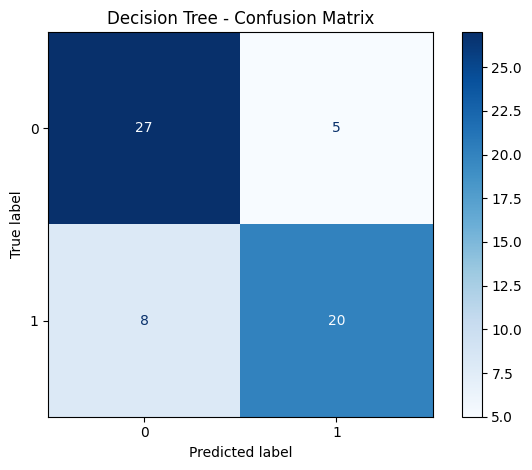

In [115]:
# Confusion Matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Decision Tree - Confusion Matrix")

plt.tight_layout()

plt.show()

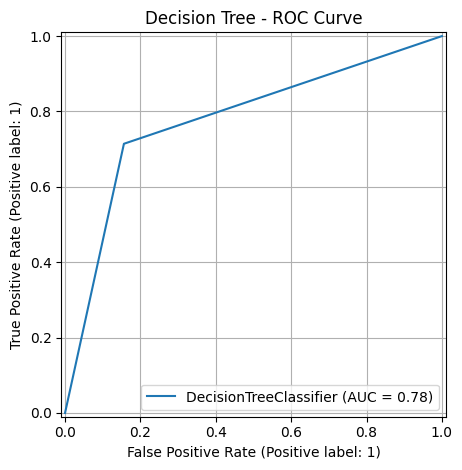

In [116]:
# ROC Curve

RocCurveDisplay.from_estimator(
    dt,
    X_test,
    y_test
)

plt.title("Decision Tree - ROC Curve")

plt.grid(True)

plt.tight_layout()

plt.show()

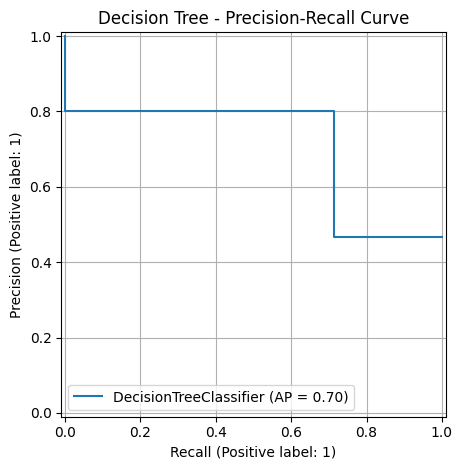

In [117]:
# Precision-Recall Curve

PrecisionRecallDisplay.from_estimator(
    dt,
    X_test,
    y_test
)

plt.title("Decision Tree - Precision-Recall Curve")

plt.grid(True)

plt.tight_layout()

plt.show()

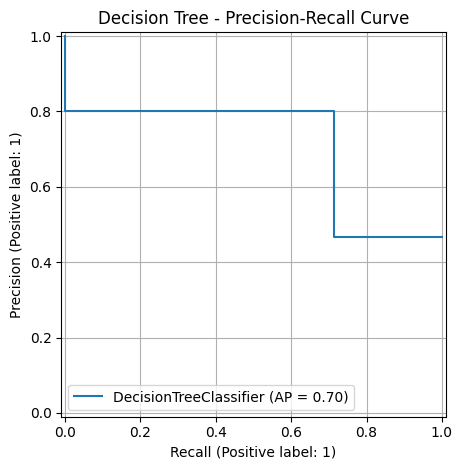

In [118]:
# Precision-Recall Curve

PrecisionRecallDisplay.from_estimator(
    dt,
    X_test,
    y_test
)

plt.title("Decision Tree - Precision-Recall Curve")

plt.grid(True)

plt.tight_layout()

plt.show()

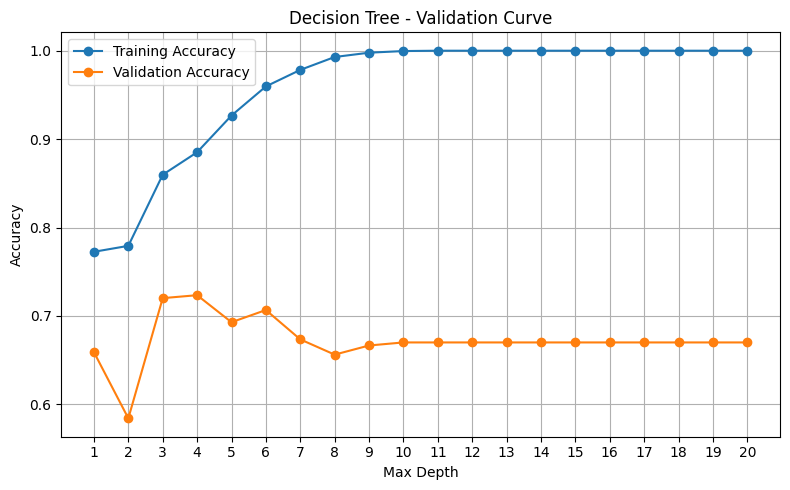

In [119]:
# Validation Curve

param_range = np.arange(1, 21)

train_scores, test_scores = validation_curve(
    DecisionTreeClassifier(
        criterion="gini",
        random_state=42
    ),
    X,
    y,
    param_name="max_depth",
    param_range=param_range,
    cv=10,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 5))

plt.plot(param_range, train_mean, marker="o", label="Training Accuracy")
plt.plot(param_range, test_mean, marker="o", label="Validation Accuracy")

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree - Validation Curve")

plt.xticks(param_range)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

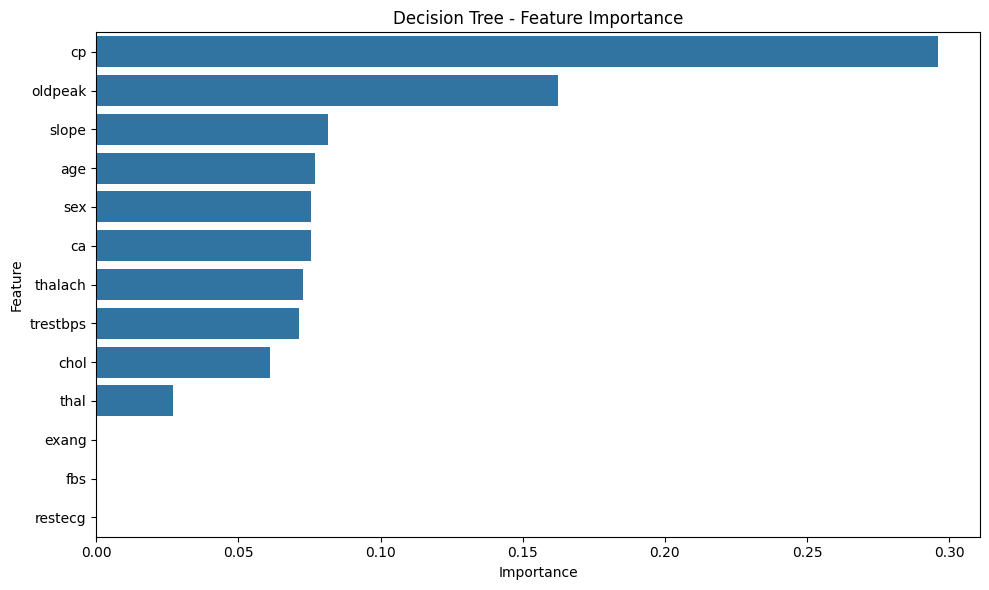

,Feature,Importance
2,cp,0.296026
9,oldpeak,0.162500
10,slope,0.081394
0,age,0.076946
1,sex,0.075676
11,ca,0.075506
7,thalach,0.072684
3,trestbps,0.071311
4,chol,0.060969
12,thal,0.026989


In [120]:
# Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree - Feature Importance")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

display(importance)

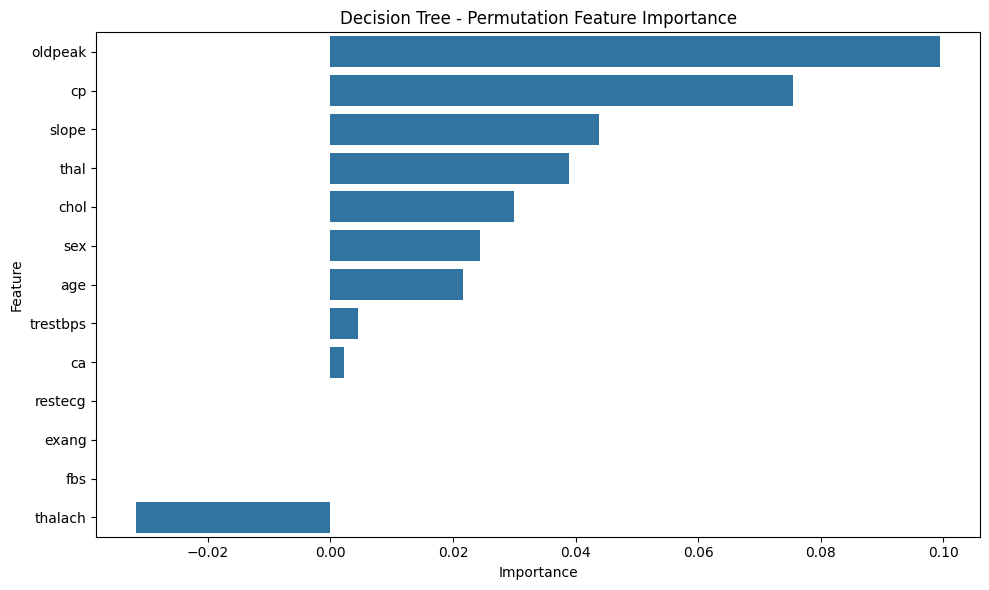

,Feature,Importance
9,oldpeak,0.099444
2,cp,0.075556
10,slope,0.043889
12,thal,0.038889
4,chol,0.030000
1,sex,0.024444
0,age,0.021667
3,trestbps,0.004444
11,ca,0.002222
6,restecg,0.000000


In [121]:
# Permutation Feature Importance

result = permutation_importance(
    dt,
    X_test,
    y_test,
    scoring="accuracy",
    n_repeats=30,
    random_state=42,
    n_jobs=-1
)

perm_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": result.importances_mean
})

perm_importance = perm_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=perm_importance,
    x="Importance",
    y="Feature"
)

plt.title("Decision Tree - Permutation Feature Importance")

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

display(perm_importance)

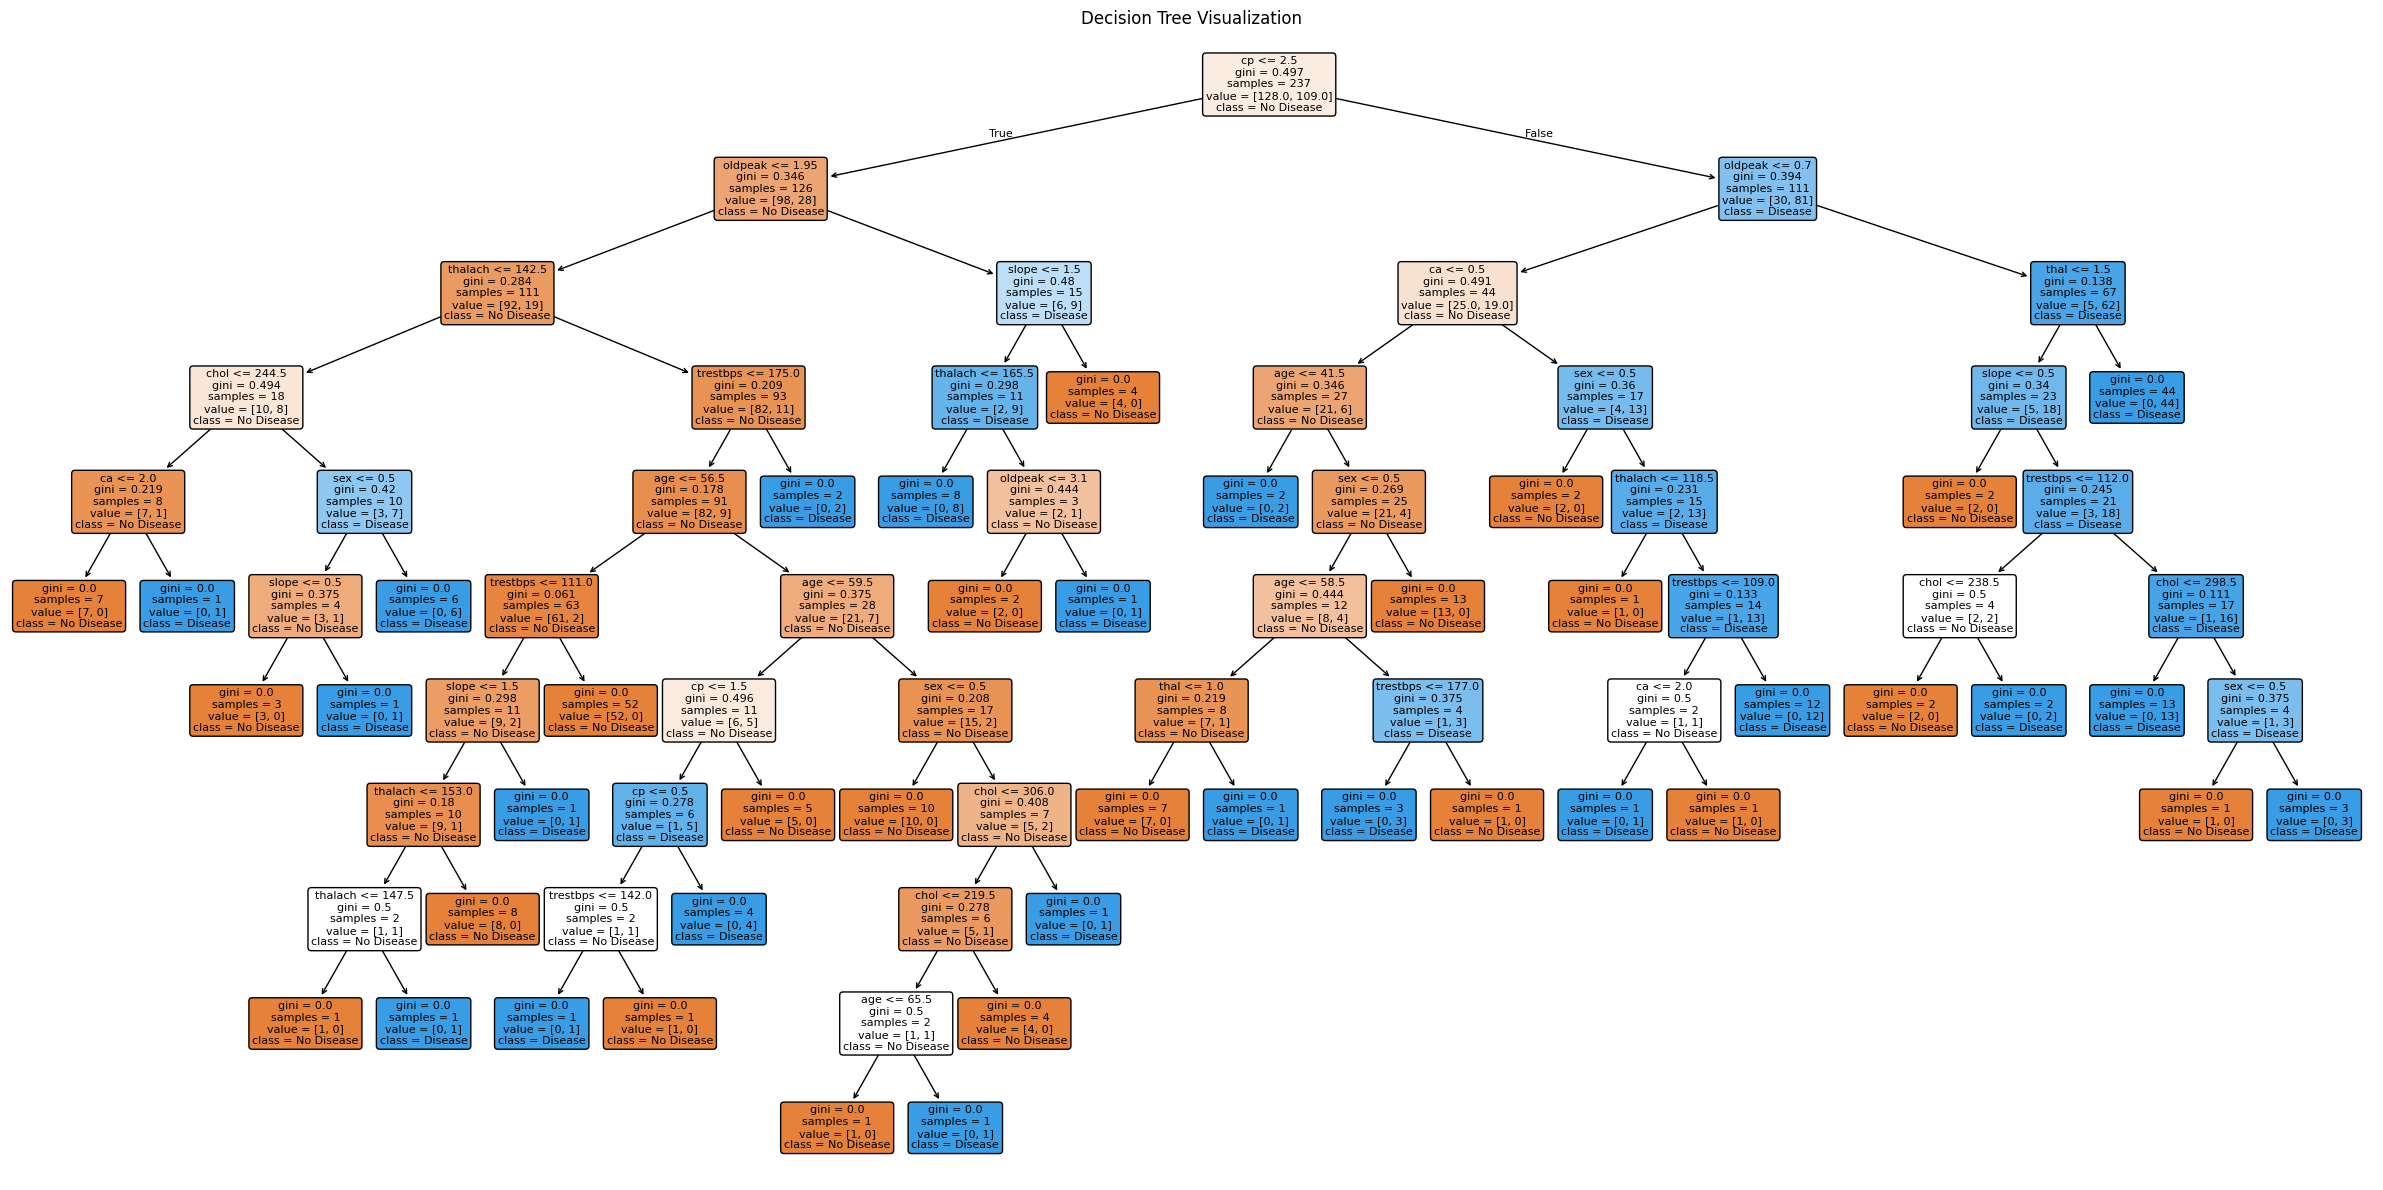

In [122]:
# Tree Visualization

plt.figure(figsize=(24, 12))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["No Disease", "Disease"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")

plt.tight_layout()
plt.show()

In [123]:
# Save Results

dt_results = {
    "Model": "Decision Tree",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc,
    "Balanced_Accuracy": balanced_acc,
    "MCC": mcc,
    "Kappa": kappa,
    "Log_Loss": loss,
    "CV_Mean": cv_mean,
    "CV_STD": cv_std,
    "Train_Time": train_time,
    "Predict_Time": test_time
}

print(dt_results)

{'Model': 'Decision Tree', 'Accuracy': 0.7833333333333333, 'Precision': 0.8, 'Recall': 0.7142857142857143, 'F1': 0.7547169811320755, 'ROC_AUC': np.float64(0.7790178571428572), 'Balanced_Accuracy': np.float64(0.7790178571428572), 'MCC': np.float64(0.5646924393157821), 'Kappa': np.float64(0.5617977528089888), 'Log_Loss': 7.809458234308717, 'CV_Mean': np.float64(0.67), 'CV_STD': np.float64(0.15942031499923823), 'Train_Time': 0.005427360534667969, 'Predict_Time': 0.00581669807434082}
